In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import movingpandas as mpd
import geopandas as gpd

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)
import warnings
warnings.simplefilter("ignore")

/Users/jonathancontreras/anaconda3/envs/spatialskmob/lib/python3.12/site-packages/movingpandas/__init__.py:37: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [2]:
os.chdir('/Users/jonathancontreras/Desktop/College Folder/Senior Year/Math485/Unit 2 Spatial')
events = pd.read_csv("Galapagos Tortoise Movement Ecology Programme_2009-2018.csv", sep=',', parse_dates=[2])
new_cols = pd.Series(events.columns.values).str.replace(pat = r"[-:]", repl="_", regex=True)
tortoise = events.set_axis(labels = new_cols, axis =1)
tortoise.drop(tortoise.index[tortoise["manually_marked_outlier"].notna()], inplace = True)
tortoise.drop(columns =["manually_marked_outlier"], inplace=True)
tortoise.drop(index = tortoise.index[tortoise.isna().any(axis=1)], inplace=True)
cols = ['event_id', 'timestamp', 'location_long', 'location_lat',
       'eobs_temperature', 'ground_speed', 'heading', 'height_above_ellipsoid',
       'individual_local_identifier', 'individual_taxon_canonical_name']
tortoise.drop(columns=tortoise.columns.difference(cols), inplace=True)

tortoise.insert(loc = 2, column = "timestamp_UTC",
                value = tortoise['timestamp'].apply(lambda x: x.tz_localize(tz='UTC'))
                )
tortoise.insert(loc = 3, column = "timestamp_local", 
                value = tortoise["timestamp_UTC"].apply(lambda x: x.tz_convert(tz='US/Pacific'))
                )
tortoise.sort_values(by = ["individual_local_identifier", "timestamp_local"], inplace=True)
tortoise.insert(loc = 4, column = "minute_diff", 
                value = tortoise.groupby(['individual_local_identifier'])["timestamp_local"].diff()\
                    .apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')
                    )
tortoise['year'] = tortoise["timestamp_local"].dt.year
tortoise['month'] = tortoise["timestamp_local"].dt.month
tortoise['date'] = tortoise["timestamp_local"].dt.date

In [3]:
tortoise.head()

,event_id,timestamp,timestamp_UTC,timestamp_local,minute_diff,location_long,location_lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,individual_local_identifier,year,month,date
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290188,46119278,2010-09-17 18:00:58.001,2010-09-17 18:00:58.001000+00:00,2010-09-17 11:00:58.001000-07:00,59,-90.242230,-0.635563,19,0.21,19.01,143.6,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290189,46119279,2010-09-17 19:00:56.001,2010-09-17 19:00:56.001000+00:00,2010-09-17 12:00:56.001000-07:00,59,-90.242210,-0.635515,22,0.15,359.14,171.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290190,46119280,2010-09-17 20:00:29.000,2010-09-17 20:00:29+00:00,2010-09-17 13:00:29-07:00,59,-90.242227,-0.635356,19,0.75,19.66,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290191,46119281,2010-09-17 21:00:56.000,2010-09-17 21:00:56+00:00,2010-09-17 14:00:56-07:00,60,-90.242101,-0.635276,17,0.08,342.75,160.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17


# Method 1: Detecting Migration Through Distance of Movement

#Define Haversine function
import math
def my_haversine(lat1, lon1, lat2, lon2):
    R = 6371e3 # in meters
    phi1 = lat1 * math.pi/180 # φ, λ in radians
    phi2 = lat2 * math.pi/180
    delta_phi = (lat2-lat1) * math.pi/180
    delta_lambda = (lon2-lon1) * math.pi/180
    a = math.sin(delta_phi/2) * math.sin(delta_phi/2) + \
        math.cos(phi1) * math.cos(phi2) * \
        math.sin(delta_lambda/2) * math.sin(delta_lambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a)) # atan2(x,y) = arctan(x/y) if y > 0
    d = R * c # unit is in meters
    return d

In [4]:
#create seperate dataframes and trajectories of each tortoise
Alison = tortoise[tortoise['individual_local_identifier']=='Alison']
gdf_alison = gpd.GeoDataFrame(Alison)
gdf_alison["geometry"] = gpd.points_from_xy(gdf_alison.location_long, gdf_alison.location_lat)

Marilyn = tortoise[tortoise['individual_local_identifier']=='Marilyn']
gdf_marilyn = gpd.GeoDataFrame(Alison)
gdf_marilyn["geometry"] = gpd.points_from_xy(gdf_marilyn.location_long, gdf_marilyn.location_lat)

Kitty = tortoise[tortoise['individual_local_identifier']=='Kitty']
gdf_kitty = gpd.GeoDataFrame(Alison)
gdf_kitty["geometry"] = gpd.points_from_xy(gdf_kitty.location_long, gdf_kitty.location_lat)

Connor = tortoise[tortoise['individual_local_identifier']=='Connor']
gdf_connor = gpd.GeoDataFrame(Alison)
gdf_connor["geometry"] = gpd.points_from_xy(gdf_connor.location_long, gdf_connor.location_lat)

Helber = tortoise[tortoise['individual_local_identifier']=='Helber']
gdf_helber = gpd.GeoDataFrame(Alison)
gdf_helber["geometry"] = gpd.points_from_xy(gdf_helber.location_long, gdf_helber.location_lat)

Christian = tortoise[tortoise['individual_local_identifier']=='Christian']
gdf_christian = gpd.GeoDataFrame(Christian)
gdf_christian["geometry"] = gpd.points_from_xy(gdf_christian.location_long, gdf_christian.location_lat)

Steve_Devine = tortoise[tortoise['individual_local_identifier']=='Steve Devine']
gdf_steve = gpd.GeoDataFrame(Steve_Devine)
gdf_steve["geometry"] = gpd.points_from_xy(gdf_steve.location_long, gdf_steve.location_lat)

In [5]:
import math
def my_haversine(lat1, lon1, lat2, lon2):
    R = 6371e3 # in meters
    phi1 = lat1 * math.pi/180 # φ, λ in radians
    phi2 = lat2 * math.pi/180
    delta_phi = (lat2-lat1) * math.pi/180
    delta_lambda = (lon2-lon1) * math.pi/180
    a = math.sin(delta_phi/2) * math.sin(delta_phi/2) + \
        math.cos(phi1) * math.cos(phi2) * \
        math.sin(delta_lambda/2) * math.sin(delta_lambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a)) # atan2(x,y) = arctan(x/y) if y > 0
    d = R * c # unit is in meters
    return d
#calculate haversine distance
def calculate_turtle_haversine(df):
    distances = [0]
    for i in range(1, len(df)):
        lat1, lon1 = df.iloc[i - 1]['location_lat'], df.iloc[i - 1]['location_long']
        lat2, lon2 = df.iloc[i]['location_lat'], df.iloc[i]['location_long']
        distance = my_haversine(lat1, lon1, lat2, lon2)
        distances.append(distance)
    return distances

#Apply haversine function to Christian DFs and create haversine column
Christian['haversine'] = calculate_turtle_haversine(Christian)

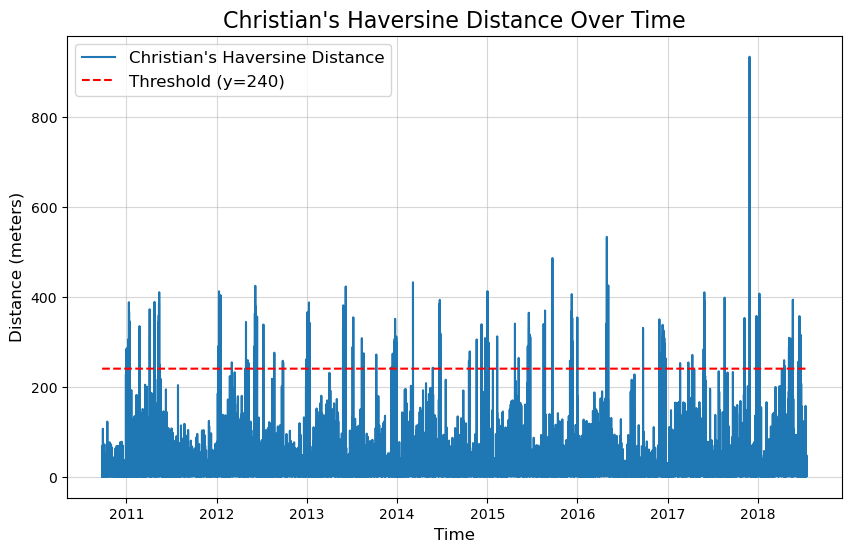

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(Christian['timestamp'], Christian['haversine'], linestyle='-', label="Christian's Haversine Distance")
plt.plot(Christian['timestamp'], [240] * len(Christian['timestamp']), label='Threshold (y=240)', color='red', linestyle='--')
plt.title("Christian's Haversine Distance Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Distance (meters)", fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)

In [7]:
Christian['migration?'] = (Christian["haversine"] > 240).astype(int)

In [8]:
print ("We have " + str(Christian['migration?'].sum()) + " hourly timestamps where Christian traveled more than 240m an an hour")

We have 345 hourly timestamps where Christian traveled more than 240m an an hour


<Axes: xlabel='timestamp_local', ylabel='migration?'>

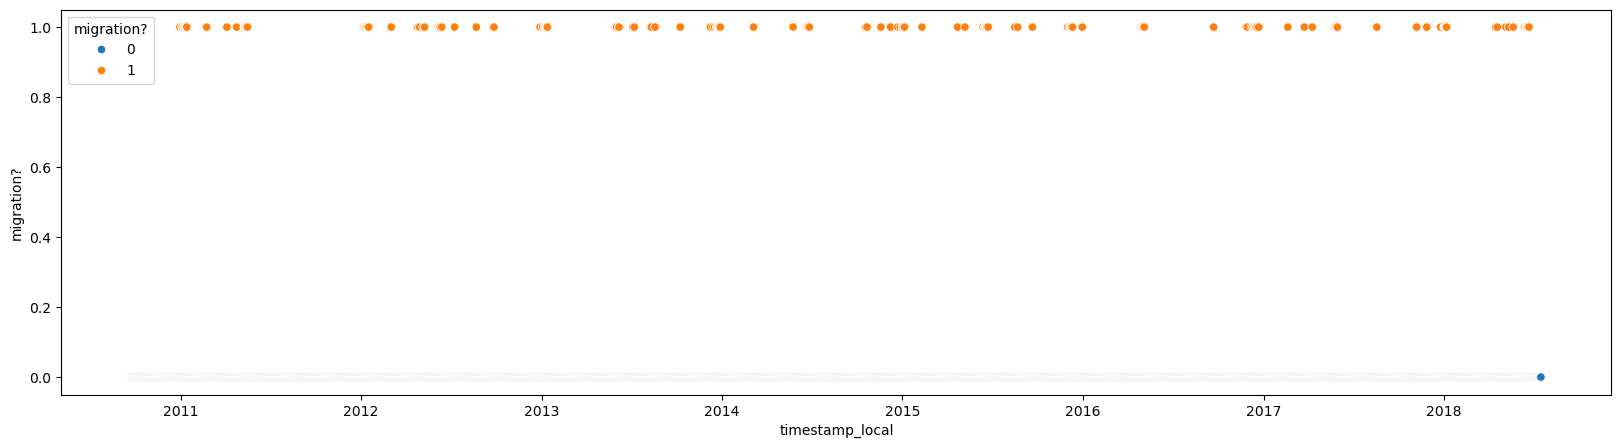

In [9]:
plt.figure(figsize = (20,5))
tortoise.query("individual_local_identifier == 'Christian' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(Christian, x = "timestamp_local", y="migration?", hue="migration?")

We found 345 possible hourly migration timestamps which is too many to verify the start and end times of migration. Perhaps we could convert this into daily migration timestamps, but it would be inefficient to do this process for all turtles. We look for another method to find migration start and end dates.

# Method 2: Finding Migration Dates Using Clustered Migration Staypoints

We use skmob to find trajectories and stay locations of turtles:

In [10]:
import skmob
christian_trajectory = skmob.TrajDataFrame(Christian, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local', \
)
christian_trajectory.head(3)

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,haversine,migration?
622339,33691506,2010-09-24 13:01:20.000,2010-09-24 13:01:20+00:00,2010-09-24 06:01:20-07:00,0,-91.092650,-0.444119,5,0.07,11.14,1115.1,Chelonoidis,Christian,2010,9,2010-09-24,0.000000,0
622340,33691507,2010-09-24 14:00:21.998,2010-09-24 14:00:21.998000+00:00,2010-09-24 07:00:21.998000-07:00,59,-91.092997,-0.444586,12,0.07,3.93,1133.9,Chelonoidis,Christian,2010,9,2010-09-24,64.677605,0
622341,77563565,2010-09-24 15:00:49.998,2010-09-24 15:00:49.998000+00:00,2010-09-24 08:00:49.998000-07:00,60,-91.093024,-0.444951,21,0.07,19.01,1105.9,Chelonoidis,Christian,2010,9,2010-09-24,40.730300,0


In [11]:
from skmob.preprocessing import detection, clustering

christian_stay_location = detection.stay_locations(christian_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)
christian_stay_location.head(3)

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,haversine,migration?,leaving_datetime
0,77564302,2010-12-30 21:00:30.000,2010-12-30 21:00:30+00:00,2010-09-24 06:01:20-07:00,59,-91.091302,-0.443379,8,0.21,342.10,1066.8,Chelonoidis,Christian,2010,12,2010-12-30,110.524000,0,2010-12-30 14:00:56.001000-08:00
1,77544056,2011-01-03 15:00:19.998,2011-01-03 15:00:19.998000+00:00,2010-12-30 14:00:56.001000-08:00,59,-91.100955,-0.453281,5,0.12,330.96,1035.4,Chelonoidis,Christian,2011,1,2011-01-03,84.624238,0,2011-01-03 08:00:24.999000-08:00
2,77544065,2011-01-04 20:00:25.000,2011-01-04 20:00:25+00:00,2011-01-03 08:00:24.999000-08:00,60,-91.112277,-0.458975,8,0.19,342.10,1047.0,Chelonoidis,Christian,2011,1,2011-01-04,212.174827,0,2011-01-04 13:00:45-08:00


In [12]:
christian_stay_cluster = clustering.cluster(
    christian_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
christian_stay_cluster = christian_stay_cluster.query("uid == 'Christian'")
christian_stay_cluster.shape[0]/christian_trajectory.shape[0], \
    christian_stay_cluster.shape[0]/christian_trajectory.shape[0]

(0.004516690583170622, 0.004516690583170622)

In [13]:
#determine which staypoint clusters to consider for visual analysis 
christian_stay_cluster.groupby("cluster").date.nunique()

cluster
0     11
1     11
2     10
3     10
4      9
5      9
6      8
7      8
8      6
9      5
10     5
11     4
12     4
13     4
14     4
15     3
16     3
17     3
18     3
19     3
20     3
21     2
22     2
23     2
24     2
25     2
26     2
27     2
28     2
29     2
30     2
31     2
32     2
33     2
34     2
35     2
36     2
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     1
47     1
48     1
49     1
50     1
51     1
52     1
53     1
54     1
55     1
56     1
57     1
58     1
59     1
60     1
61     1
62     1
63     1
64     1
65     1
66     1
67     1
68     1
69     1
70     1
Name: date, dtype: int64

In [14]:
start_year = 2010
end_year = 2020
year_list = range(start_year, end_year)
month_date_str = '05-01'
s_date = []
for i in range(start_year, end_year+1):
    s_date.append(pd.Timestamp(str(i)+'-' +month_date_str).tz_localize(tz = 'US/Pacific'))
e_date = s_date[1:]
s_date.pop()
pal = sns.color_palette('tab10')
color_list = pal.as_hex()

In [15]:
christian_plot = christian_trajectory.plot_trajectory(zoom=14, tiles="OpenStreetMap")
christian_stay_cluster[christian_stay_cluster["cluster"] == 0].plot_stops(map_f = christian_plot, hex_color = color_list[0], zoom=14, radius = 4)
christian_stay_cluster[christian_stay_cluster["cluster"] == 1].plot_stops(map_f = christian_plot, hex_color = color_list[1], radius =4)
christian_stay_cluster[christian_stay_cluster["cluster"] == 2].plot_stops(map_f = christian_plot, hex_color = color_list[2], radius = 4)
christian_stay_cluster[christian_stay_cluster["cluster"] == 3].plot_stops(map_f = christian_plot, hex_color = color_list[3], radius = 4)
christian_plot

In [16]:
#From plot, we determine stop and end stay locations of migration are clusters 1 and 2
christian_migration_cluster = christian_stay_cluster[christian_stay_cluster['cluster'].isin([1, 2])]
christians_migration = christian_migration_cluster[['datetime', 'leaving_datetime']]

In [17]:
christians_migration
#Below is Christian's migration start and end times where we have the format YYY-MM-DD HH:MM:SS-UTC-7

,datetime,leaving_datetime
0,2010-09-24 06:01:20-07:00,2010-12-30 14:00:56.001000-08:00
11,2011-01-13 07:00:31-08:00,2011-01-16 09:00:50.998000-08:00
12,2011-01-16 09:00:50.998000-08:00,2011-05-09 11:00:50-07:00
24,2011-05-20 09:00:24-07:00,2012-01-06 10:00:56.999000-08:00
35,2012-01-16 14:00:55.998000-08:00,2012-02-22 09:00:43.998000-08:00
36,2012-02-22 09:00:43.998000-08:00,2012-06-02 06:00:25.998000-07:00
48,2012-06-19 11:00:49.998000-07:00,2012-12-28 10:00:56-08:00
60,2013-01-12 10:00:56-08:00,2013-05-27 06:00:16.999000-07:00
72,2013-06-08 14:00:13-07:00,2013-12-13 10:00:25-08:00
84,2013-12-29 11:00:24.999000-08:00,2014-06-19 09:00:15.001000-07:00


# Results

In [18]:
alison_trajectory = skmob.TrajDataFrame(Alison, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)
marilyn_trajectory = skmob.TrajDataFrame(Marilyn, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)
kitty_trajectory = skmob.TrajDataFrame(Kitty, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)
connor_trajectory = skmob.TrajDataFrame(Connor, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)
helber_trajectory = skmob.TrajDataFrame(Helber, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)
steve_trajectory = skmob.TrajDataFrame(Steve_Devine, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local',)

In [19]:
alison_stay_location = detection.stay_locations(alison_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)
marilyn_stay_location = detection.stay_locations(marilyn_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)
kitty_stay_location = detection.stay_locations(kitty_trajectory, 
    stop_radius_factor=0.6, minutes_for_a_stop=400,
    spatial_radius_km=0.35, leaving_time=True)
connor_stay_location = detection.stay_locations(connor_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)
helber_stay_location = detection.stay_locations(helber_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)
steve_stay_location = detection.stay_locations(steve_trajectory, 
    stop_radius_factor=1, minutes_for_a_stop=200,
    spatial_radius_km=1, leaving_time=True)

In [20]:
alison_stay_cluster = clustering.cluster(
    alison_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
alison_stay_cluster = alison_stay_cluster.query("uid == 'Alison'")
alison_stay_cluster.shape[0]/alison_trajectory.shape[0], \
    alison_stay_cluster.shape[0]/alison_trajectory.shape[0]
marilyn_stay_cluster = clustering.cluster(
    marilyn_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
marilyn_stay_cluster = marilyn_stay_cluster.query("uid == 'Marilyn'")
marilyn_stay_cluster.shape[0]/marilyn_trajectory.shape[0], \
    marilyn_stay_cluster.shape[0]/marilyn_trajectory.shape[0]
kitty_stay_cluster = clustering.cluster(
    kitty_stay_location, 
    cluster_radius_km=0.0075, min_samples=1)
kitty_stay_cluster = kitty_stay_cluster.query("uid == 'Kitty'")
kitty_stay_cluster.shape[0]/kitty_trajectory.shape[0], \
    kitty_stay_cluster.shape[0]/kitty_trajectory.shape[0]
connor_stay_cluster = clustering.cluster(
    connor_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
connor_stay_cluster = connor_stay_cluster.query("uid == 'Connor'")
connor_stay_cluster.shape[0]/connor_trajectory.shape[0], \
    connor_stay_cluster.shape[0]/connor_trajectory.shape[0]
helber_stay_cluster = clustering.cluster(
    helber_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
helber_stay_cluster = helber_stay_cluster.query("uid == 'Helber'")
helber_stay_cluster.shape[0]/helber_trajectory.shape[0], \
    helber_stay_cluster.shape[0]/helber_trajectory.shape[0]
steve_stay_cluster = clustering.cluster(
    steve_stay_location, 
    cluster_radius_km=0.1, min_samples=1)
steve_stay_cluster = steve_stay_cluster.query("uid == 'Steve Devine'")
steve_stay_cluster.shape[0]/steve_trajectory.shape[0], \
    steve_stay_cluster.shape[0]/steve_trajectory.shape[0]

(0.003396885391000646, 0.003396885391000646)

In [21]:
alison_migration_cluster = alison_stay_cluster[alison_stay_cluster['cluster'].isin([0, 1])]
alisons_migration = alison_migration_cluster[['datetime', 'leaving_datetime']]
alisons_migration

,datetime,leaving_datetime
0,2010-09-17 10:01:25.998000-07:00,2012-10-23 07:00:50-07:00
4,2012-12-27 13:01:17.998000-08:00,2013-04-07 10:01:05.001000-07:00
5,2013-04-07 10:01:05.001000-07:00,2013-05-20 12:00:49.998000-07:00
9,2013-06-24 09:01:22.998000-07:00,2013-10-02 13:00:43.998000-07:00
17,2014-06-23 10:00:50.001000-07:00,2015-10-26 12:00:15.001000-07:00
21,2015-11-12 14:01:13.999000-08:00,2016-05-19 13:00:49.999000-07:00
24,2016-06-19 10:00:56-07:00,2017-11-02 11:01:26.001000-07:00
27,2017-11-23 10:00:24.998000-08:00,2018-06-25 09:00:56-07:00
28,2018-06-25 09:00:56-07:00,2018-10-01 09:00:29.998000-07:00


In [23]:
marilyn_migration_cluster = marilyn_stay_cluster[marilyn_stay_cluster['cluster'].isin([3,0])]
marilyns_migration = marilyn_migration_cluster[['datetime', 'leaving_datetime']]
marilyns_migration

,datetime,leaving_datetime
0,2010-09-17 11:01:31.998000-07:00,2011-03-16 08:00:13.998000-07:00
3,2011-09-15 08:00:23-07:00,2011-09-22 09:00:43.999000-07:00
4,2011-09-22 09:00:43.999000-07:00,2012-02-05 07:00:44.001000-08:00
8,2012-03-12 06:00:56.998000-07:00,2012-03-29 06:00:55.999000-07:00
11,2012-08-29 10:00:55.999000-07:00,2012-09-14 08:00:15-07:00
12,2012-09-14 08:00:15-07:00,2013-03-15 07:00:14.998000-07:00
15,2013-08-19 14:00:39-07:00,2013-09-01 09:00:38-07:00
16,2013-09-01 09:00:38-07:00,2014-04-06 06:00:11-07:00
19,2014-06-08 12:00:56.001000-07:00,2014-06-12 07:00:44.001000-07:00
20,2014-06-12 07:00:44.001000-07:00,2014-12-08 07:00:28-08:00


In [24]:
#Kitty's migration does not account for her irregular movements in 2013-2017, this algorithm was not effective
kitty_migration_cluster = kitty_stay_cluster[kitty_stay_cluster['cluster'].isin([1, 0])]
kittys_migration = kitty_migration_cluster[['datetime', 'leaving_datetime']]
kittys_migration

,datetime,leaving_datetime
2,2012-07-11 04:00:44-07:00,2012-08-15 14:00:22-07:00
3,2012-08-15 14:00:22-07:00,2012-08-18 08:00:27.998000-07:00
18,2018-08-07 13:00:16.998000-07:00,2018-08-15 07:00:33.001000-07:00
19,2018-08-15 07:00:33.001000-07:00,2018-08-18 13:00:32.998000-07:00
20,2018-08-18 13:00:32.998000-07:00,2018-10-01 09:00:29.998000-07:00


In [25]:
connor_migration_cluster = connor_stay_cluster[connor_stay_cluster['cluster'].isin([1, 3])]
connors_migration = connor_migration_cluster[['datetime', 'leaving_datetime']]
connors_migration

,datetime,leaving_datetime
0,2010-09-21 13:01:31.999000-07:00,2011-01-12 05:00:43.999000-08:00
11,2011-10-15 10:00:40.999000-07:00,2012-02-05 07:00:50.001000-08:00
17,2012-09-13 11:00:56.001000-07:00,2012-10-24 11:00:56.998000-07:00
18,2012-10-24 11:00:56.998000-07:00,2013-02-14 14:00:43.998000-08:00
22,2013-02-20 08:01:11-08:00,2013-08-14 14:00:44.999000-07:00
25,2013-08-20 11:00:55.998000-07:00,2013-09-13 13:00:49.998000-07:00
27,2013-09-23 14:00:34.998000-07:00,2013-10-02 12:00:21.998000-07:00
28,2013-10-02 12:00:21.998000-07:00,2014-01-10 09:00:26.998000-08:00
32,2014-01-19 13:00:43.998000-08:00,2014-09-30 10:00:56.001000-07:00
36,2014-10-26 08:00:37.001000-07:00,2015-03-21 15:00:56.001000-07:00


In [26]:
helber_migration_cluster = helber_stay_cluster[helber_stay_cluster['cluster'].isin([1, 2])]
helbers_migration = helber_migration_cluster[['datetime', 'leaving_datetime']]
helbers_migration

,datetime,leaving_datetime
0,2009-04-29 09:00:50-07:00,2009-05-11 06:00:56-07:00
5,2009-05-27 10:00:33.998000-07:00,2009-10-11 07:00:16.001000-07:00
15,2010-04-04 09:00:56.998000-07:00,2010-09-24 11:00:29.001000-07:00
19,2010-10-11 09:01:02-07:00,2010-11-07 12:00:45-08:00
22,2010-12-04 14:00:55.998000-08:00,2011-02-23 12:01:55.001000-08:00
27,2011-04-30 09:00:55.998000-07:00,2011-12-21 08:00:49.999000-08:00


In [27]:
steve_migration_cluster = steve_stay_cluster[steve_stay_cluster['cluster'].isin([4, 5])]
steves_migration = steve_migration_cluster[['datetime', 'leaving_datetime']]
steves_migration

,datetime,leaving_datetime
8,2011-03-05 08:00:33.001000-08:00,2011-06-18 14:00:43.998000-07:00
16,2011-08-21 16:00:15.001000-07:00,2011-11-26 11:00:50-08:00
24,2012-02-25 12:00:39.001000-08:00,2012-06-15 14:00:43.999000-07:00
32,2012-08-14 12:00:12.001000-07:00,2013-01-13 11:00:26.998000-08:00
40,2013-03-01 07:00:56.999000-08:00,2013-04-23 11:00:44.001000-07:00
56,2014-02-16 09:00:50.001000-08:00,2014-03-22 07:01:25.998000-07:00
72,2014-10-06 18:00:55.998000-07:00,2015-01-06 10:01:12.999000-08:00
80,2015-02-19 07:00:55.998000-08:00,2015-07-26 13:01:14-07:00
88,2015-10-01 16:00:27-07:00,2016-01-09 09:00:22.999000-08:00
96,2016-02-08 15:00:19.998000-08:00,2016-04-07 07:00:45.999000-07:00
